# Retail Demand Forecasting — Store Sales (Corporacion Favorita)

Data Science Internship Project — Final Presentation Notebook — Codec Technologies

Forecasting daily unit sales per store x product-family for a 54-store Ecuadorian grocery chain, using historical sales, promotions, holidays, and oil price as inputs. Comparing naive baselines, ARIMA, Prophet, Random Forest, XGBoost, and an LSTM, evaluated on RMSE, MAPE, WAPE, and forecast bias.

Dataset: [Store Sales - Time Series Forecasting (Kaggle competition)](https://www.kaggle.com/competitions/store-sales-time-series-forecasting)

Structured as Ask -> Prepare -> Process -> Analyze -> Share -> Act.

---

**Contents**
1. Ask — Define the Business Task
2. Prepare — Source and Assess the Data *(expanded dataset overview + EDA)*
3. Process — Clean and Engineer Features
4. Analyze — Model Building and Comparison (experiment matrix + tuning + deployable final-model selection)
5. Share — Visualize and Communicate Findings
6. Act — Recommendations and Next Steps


## 1. Ask - Define the Business Task

Goal: forecast daily unit sales for each store x product-family combination, one day ahead, evaluated over a 15-day held-out window, to support inventory replenishment decisions.

Scope note: the lag/rolling features use actuals through the previous day, so the naive, Random Forest, XGBoost and LSTM models are one-step-ahead forecasters. ARIMA and Prophet forecast the whole window from a single origin (multi-step), so they are not like-for-like with the others. A true 15-day-ahead evaluation would need horizon-safe features (lags of 15+ days or recursive forecasting) and is not done here.

The forecaster isn't the decision-maker here - the point is an unbiased, useful forecast planners can act on, not a number tuned to look good on one metric.

Target: company-wide WAPE <= 15% and RMSE below the naive-baseline RMSE on the held-out 15-day window, for at least 80% of product families.


In [55]:
import logging
import os
import warnings

warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import xgboost as xgb
from prophet import Prophet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tensorflow import keras
from tensorflow.keras import layers

logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

ASSETS_DIR = "assets"
os.makedirs(ASSETS_DIR, exist_ok=True)

print("Environment ready.")

Environment ready.


## 2. Prepare - Source and Assess the Data

Downloaded via the Kaggle competition CLI into `data/` - 6 linked files. Comprehensive (~3M rows) and Reliable, but `oil.csv` has gaps that need addressing, and this records realized *sales*, not true *demand* - stockouts can under-report demand on some days. Worth flagging as a limitation up front rather than assuming sales = demand.


In [56]:
DATA_DIR = "data"

train = pd.read_csv(
    f"{DATA_DIR}/train.csv",
    parse_dates=["date"],
    dtype={"store_nbr": "int16", "family": "category", "onpromotion": "int32", "sales": "float32"},
)
test = pd.read_csv(
    f"{DATA_DIR}/test.csv",
    parse_dates=["date"],
    dtype={"store_nbr": "int16", "family": "category", "onpromotion": "int32"},
)
stores = pd.read_csv(
    f"{DATA_DIR}/stores.csv",
    dtype={"store_nbr": "int16", "city": "category", "state": "category", "type": "category", "cluster": "int16"},
)
oil = pd.read_csv(f"{DATA_DIR}/oil.csv", parse_dates=["date"], dtype={"dcoilwtico": "float32"})
holidays = pd.read_csv(
    f"{DATA_DIR}/holidays_events.csv",
    parse_dates=["date"],
    dtype={"type": "category", "locale": "category", "locale_name": "category"},
)
transactions = pd.read_csv(
    f"{DATA_DIR}/transactions.csv",
    parse_dates=["date"],
    dtype={"store_nbr": "int16", "transactions": "int32"},
)

print(f"train:        {train.shape}")
print(f"test:         {test.shape}")
print(f"stores:       {stores.shape}")
print(f"oil:          {oil.shape}")
print(f"holidays:     {holidays.shape}")
print(f"transactions: {transactions.shape}")

train:        (3000888, 6)
test:         (28512, 5)
stores:       (54, 5)
oil:          (1218, 2)
holidays:     (350, 6)
transactions: (83488, 3)


### Dataset overview - one function, applied to each file

In [57]:
def dataset_overview(data, name):
    """Shape, dtypes, memory, missing values, duplicates, date range - the
    same one-stop summary used for the fraud-detection project, generalized
    to any of the 6 files here."""
    print("=" * 60)
    print(f"{name}: {data.shape[0]:,} rows x {data.shape[1]} columns")
    print(f"Memory usage: {data.memory_usage(deep=True).sum() / 1e6:.1f} MB")

    missing = data.isnull().sum()
    if missing.sum() > 0:
        print("\nMissing values:")
        print(missing[missing > 0])
    else:
        print("\nMissing values: none")

    print(f"Duplicate rows: {data.duplicated().sum():,}")

    if "date" in data.columns:
        print(f"Date range: {data['date'].min().date()} to {data['date'].max().date()}")


for name, data in [
    ("train", train), ("test", test), ("stores", stores),
    ("oil", oil), ("holidays", holidays), ("transactions", transactions),
]:
    dataset_overview(data, name)
    print()

train: 3,000,888 rows x 6 columns
Memory usage: 81.0 MB

Missing values: none
Duplicate rows: 0
Date range: 2013-01-01 to 2017-08-15

test: 28,512 rows x 5 columns
Memory usage: 0.7 MB

Missing values: none
Duplicate rows: 0
Date range: 2017-08-16 to 2017-08-31

stores: 54 rows x 5 columns
Memory usage: 0.0 MB

Missing values: none
Duplicate rows: 0

oil: 1,218 rows x 2 columns
Memory usage: 0.0 MB

Missing values:
dcoilwtico    43
dtype: int64
Duplicate rows: 0
Date range: 2013-01-01 to 2017-08-31

holidays: 350 rows x 6 columns
Memory usage: 0.0 MB

Missing values: none
Duplicate rows: 0
Date range: 2012-03-02 to 2017-12-26

transactions: 83,488 rows x 3 columns
Memory usage: 1.2 MB

Missing values: none
Duplicate rows: 0
Date range: 2013-01-01 to 2017-08-15



### Store network summary

In [58]:
def store_network_summary(stores_df):
    """Counts by city, state, type, and cluster - the dimensions any sales
    breakdown below will be sliced along."""
    print(f"Total stores: {len(stores_df)}")

    print(f"\nStores per type:")
    print(stores_df["type"].value_counts())

    print(f"\nStores per cluster (top 5 of {stores_df['cluster'].nunique()} clusters):")
    print(stores_df["cluster"].value_counts().head())

    print(f"\nStores per state (top 10 of {stores_df['state'].nunique()} states):")
    print(stores_df["state"].value_counts().head(10))

    print(f"\nStores per city (top 10 of {stores_df['city'].nunique()} cities):")
    print(stores_df["city"].value_counts().head(10))


store_network_summary(stores)

Total stores: 54

Stores per type:
type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype: int64

Stores per cluster (top 5 of 17 clusters):
cluster
3     7
6     6
10    6
15    5
13    4
Name: count, dtype: int64

Stores per state (top 10 of 16 states):
state
Pichincha                         19
Guayas                            11
Azuay                              3
Manabi                             3
Santo Domingo de los Tsachilas     3
Cotopaxi                           2
El Oro                             2
Los Rios                           2
Tungurahua                         2
Bolivar                            1
Name: count, dtype: int64

Stores per city (top 10 of 22 cities):
city
Quito            18
Guayaquil         8
Cuenca            3
Santo Domingo     3
Ambato            2
Latacunga         2
Machala           2
Manta             2
Babahoyo          1
Cayambe           1
Name: count, dtype: int64


### Numeric feature summary statistics

In [59]:
def numeric_summary(data, cols):
    """describe() plus skewness/kurtosis - useful for spotting the heavy
    right-skew typical of retail sales data."""
    summary = data[cols].describe().T
    summary["skew"] = data[cols].skew()
    summary["kurtosis"] = data[cols].kurt()
    return summary.round(2)


print(numeric_summary(train, ["sales", "onpromotion"]))
print()
print(numeric_summary(oil, ["dcoilwtico"]))
print()
print(numeric_summary(transactions, ["transactions"]))

                 count    mean      std  min  25%   50%     75%       max  \
sales        3000888.0  357.78  1102.00  0.0  0.0  11.0  195.85  124717.0   
onpromotion  3000888.0    2.60    12.22  0.0  0.0   0.0    0.00     741.0   

              skew  kurtosis  
sales         7.36    154.56  
onpromotion  11.17    240.87  

             count   mean    std    min   25%    50%    75%     max  skew  \
dcoilwtico  1175.0  67.71  25.63  26.19  46.4  53.19  95.66  110.62  0.32   

            kurtosis  
dcoilwtico     -1.61  

                count    mean     std  min     25%     50%     75%     max  \
transactions  83488.0  1694.6  963.29  5.0  1046.0  1393.0  2079.0  8359.0   

              skew  kurtosis  
transactions  1.52      2.57  


### Categorical feature summary

In [60]:
def categorical_summary(data, col):
    """Value counts + percentage share for a categorical column."""
    counts = data[col].value_counts()
    pct = data[col].value_counts(normalize=True) * 100
    return pd.DataFrame({"count": counts, "pct_%": pct.round(2)})


categorical_summary(train, "family")

,count,pct_%
family,,
AUTOMOTIVE,90936,3.03
BABY CARE,90936,3.03
BEAUTY,90936,3.03
BEVERAGES,90936,3.03
BOOKS,90936,3.03
BREAD/BAKERY,90936,3.03
CELEBRATION,90936,3.03
CLEANING,90936,3.03
DAIRY,90936,3.03


### How many series, and are they complete?

In [61]:
n_stores = train["store_nbr"].nunique()
n_families = train["family"].nunique()
n_series = train.groupby(["store_nbr", "family"], observed=True).ngroups

print(f"Stores: {n_stores}")
print(f"Product families: {n_families}")
print(f"Store x family series: {n_series}")

full_date_range = pd.date_range(train["date"].min(), train["date"].max(), freq="D")
expected_days = len(full_date_range)

series_lengths = train.groupby(["store_nbr", "family"], observed=True)["date"].nunique()
incomplete_series = (series_lengths != expected_days).sum()

print(f"\nExpected days per complete series: {expected_days}")
print(f"Series with at least one missing day: {incomplete_series} of {n_series} "
      f"({incomplete_series / n_series * 100:.1f}%)")

Stores: 54
Product families: 33
Store x family series: 1782

Expected days per complete series: 1688
Series with at least one missing day: 1782 of 1782 (100.0%)


### Missing-day distribution across series

In [62]:
def missing_days_per_series(data, full_range):
    """How many missing calendar days does each store x family series have?
    A distribution across all series, to check whether gaps are a handful of
    days each or something more systemic (a full histogram is plotted in the
    EDA section below)."""
    counts = data.groupby(["store_nbr", "family"], observed=True)["date"].nunique()
    missing = len(full_range) - counts
    return missing


missing_per_series = missing_days_per_series(train, full_date_range)
print(missing_per_series.describe())

count    1782.0
mean        4.0
std         0.0
min         4.0
25%         4.0
50%         4.0
75%         4.0
max         4.0
Name: date, dtype: float64


### Oil price gaps

In [63]:
oil_full = oil.set_index("date").reindex(full_date_range)
missing_oil_pct = oil_full["dcoilwtico"].isnull().mean() * 100
print(f"Missing oil-price days: {missing_oil_pct:.1f}% of the full date range")

Missing oil-price days: 31.1% of the full date range


### Holiday types and the transferred flag

In [64]:
print(holidays["type"].value_counts())
print(f"\nTransferred=True rows: {holidays['transferred'].sum()} "
      f"(these do NOT count as a holiday on their listed date - see Process)")

type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

Transferred=True rows: 12 (these do NOT count as a holiday on their listed date - see Process)


## Exploratory Data Analysis

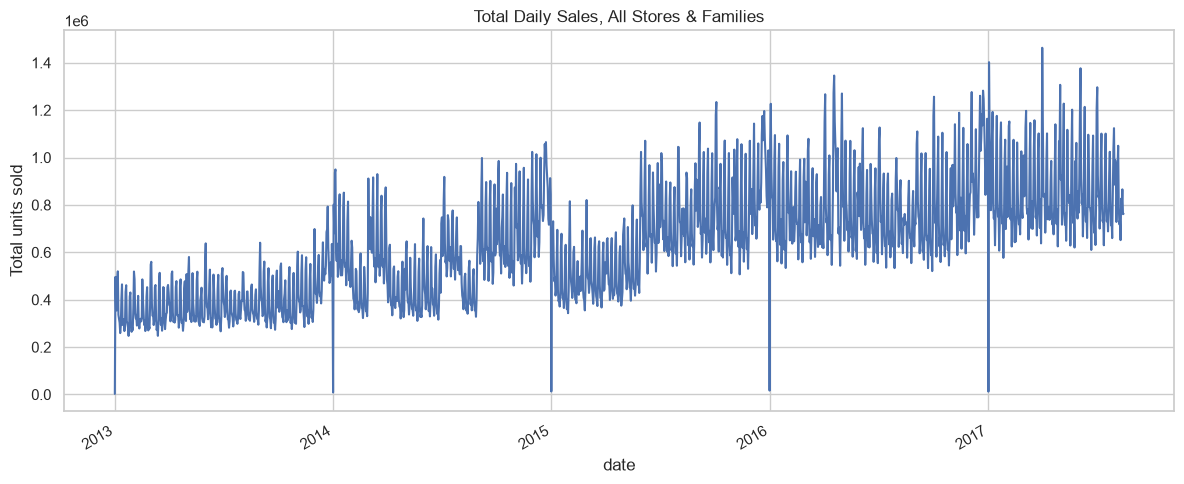

In [65]:
def plot_total_sales_over_time(data):
    daily_total = data.groupby("date", observed=True)["sales"].sum()
    plt.figure(figsize=(12, 5))
    daily_total.plot(color="#4C72B0")
    plt.title("Total Daily Sales, All Stores & Families")
    plt.ylabel("Total units sold")
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/01_total_sales_over_time.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_total_sales_over_time(train)

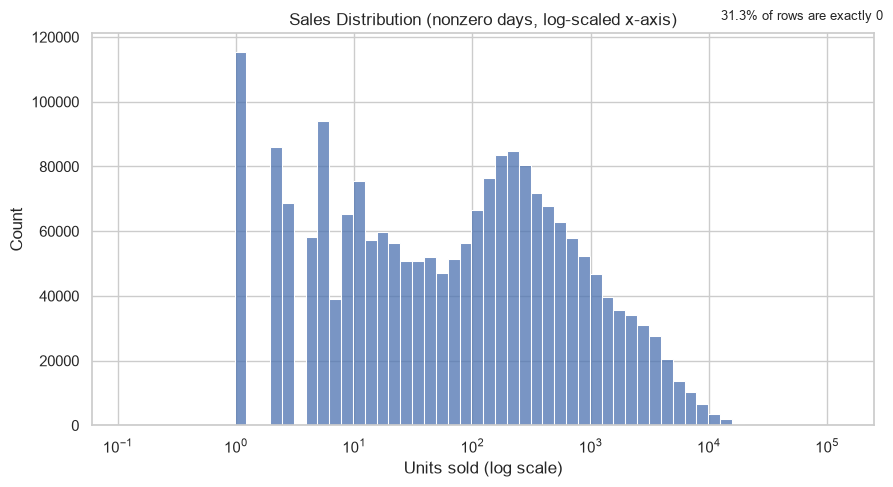

Zero-sales rows: 31.3% - many series are intermittent, which is exactly why MAPE alone is a poor metric here.


In [66]:
def plot_sales_distribution(data):
    plt.figure(figsize=(9, 5))
    sns.histplot(data["sales"][data["sales"] > 0], bins=60, log_scale=(True, False), color="#4C72B0")
    plt.title("Sales Distribution (nonzero days, log-scaled x-axis)")
    plt.xlabel("Units sold (log scale)")
    zero_pct = (data["sales"] == 0).mean() * 100
    plt.figtext(0.99, 0.95, f"{zero_pct:.1f}% of rows are exactly 0", ha="right", fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/02_sales_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Zero-sales rows: {zero_pct:.1f}% - many series are intermittent, which is exactly "
          f"why MAPE alone is a poor metric here.")


plot_sales_distribution(train)

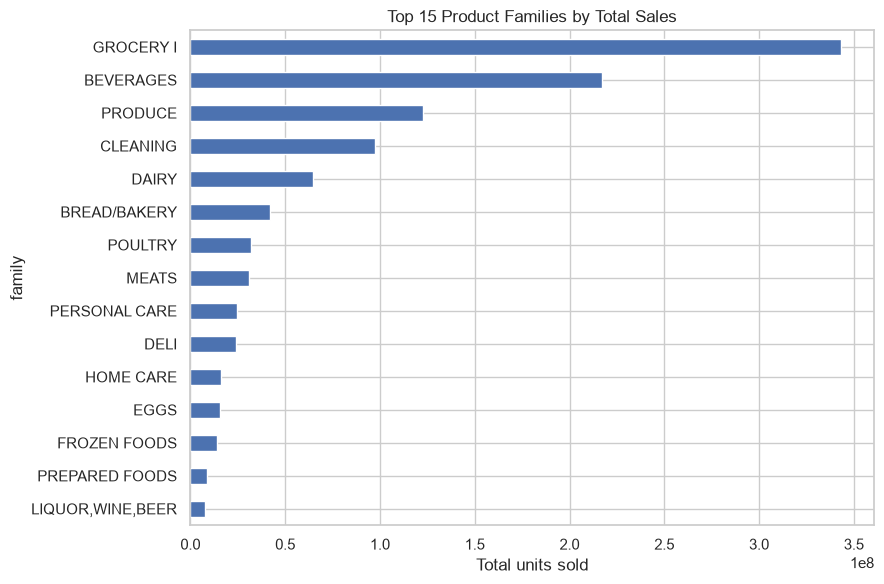

In [67]:
def plot_sales_by_family(data, top_n=15):
    top_families = data.groupby("family", observed=True)["sales"].sum().sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(9, 6))
    top_families.plot(kind="barh", color="#4C72B0")
    plt.gca().invert_yaxis()
    plt.title(f"Top {top_n} Product Families by Total Sales")
    plt.xlabel("Total units sold")
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/03_sales_by_family.png", dpi=150, bbox_inches="tight")
    plt.show()
    return top_families


top_families = plot_sales_by_family(train)

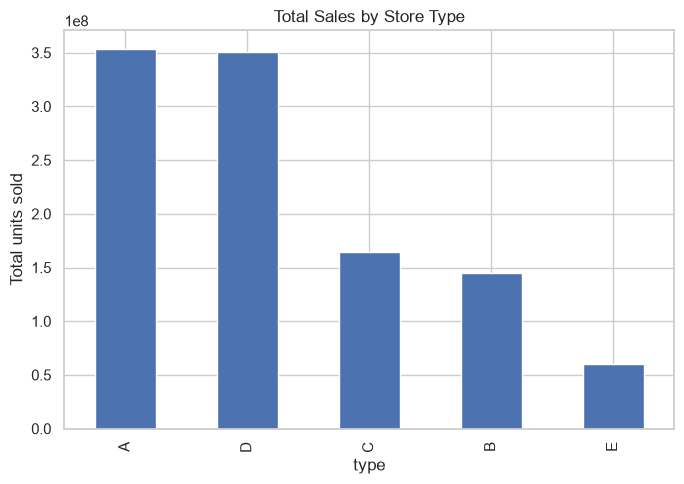

In [68]:
def plot_sales_by_store_type(data, stores_df):
    merged = data.merge(stores_df[["store_nbr", "type"]], on="store_nbr", how="left")
    by_type = merged.groupby("type", observed=True)["sales"].sum().sort_values(ascending=False)
    plt.figure(figsize=(7, 5))
    by_type.plot(kind="bar", color="#4C72B0")
    plt.title("Total Sales by Store Type")
    plt.ylabel("Total units sold")
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/04_sales_by_store_type.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_sales_by_store_type(train, stores)

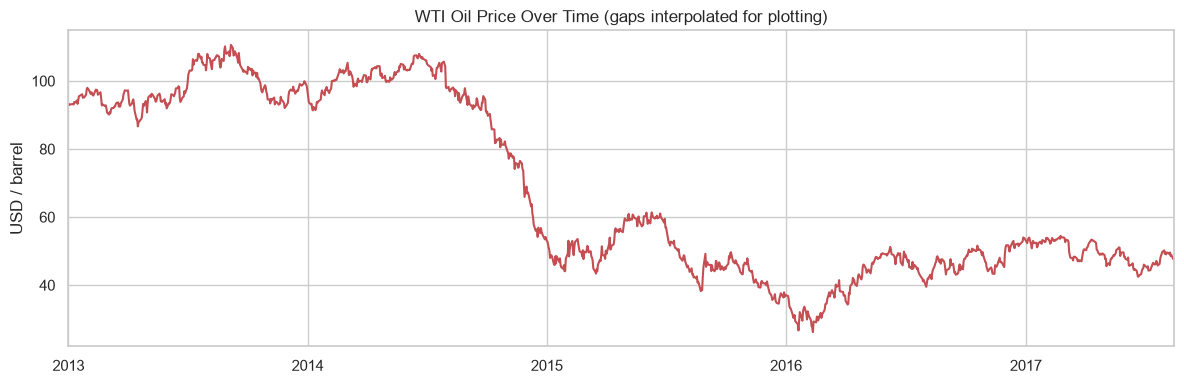

In [69]:
def plot_oil_price(oil_df, full_range):
    filled = oil_df.set_index("date").reindex(full_range)["dcoilwtico"].interpolate()
    plt.figure(figsize=(12, 4))
    filled.plot(color="#C44E52")
    plt.title("WTI Oil Price Over Time (gaps interpolated for plotting)")
    plt.ylabel("USD / barrel")
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/05_oil_price_over_time.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_oil_price(oil, full_date_range)

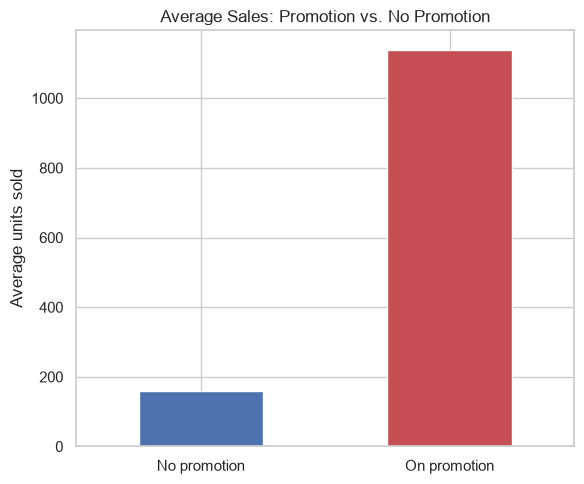

No promotion     158.246674
On promotion    1137.693726
Name: sales, dtype: float32


In [70]:
def plot_promotion_effect(data):
    has_promo = data["onpromotion"] > 0
    avg_sales = data.groupby(has_promo)["sales"].mean()
    avg_sales.index = ["No promotion", "On promotion"]
    plt.figure(figsize=(6, 5))
    avg_sales.plot(kind="bar", color=["#4C72B0", "#C44E52"])
    plt.title("Average Sales: Promotion vs. No Promotion")
    plt.ylabel("Average units sold")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/06_promotion_effect.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(avg_sales)


plot_promotion_effect(train)

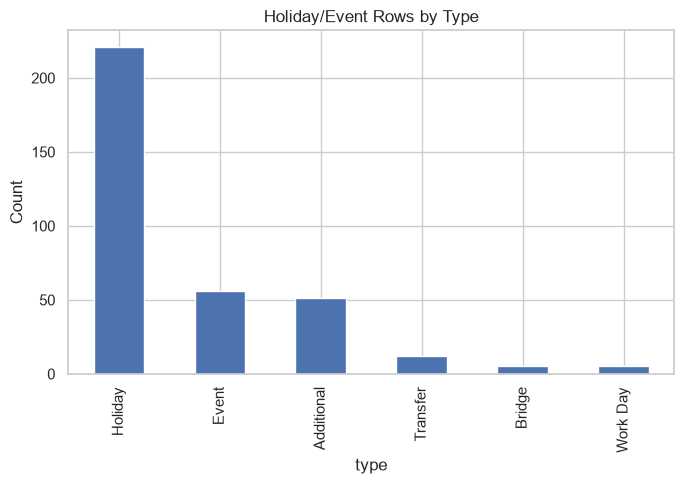

In [71]:
def plot_holiday_counts(holidays_df):
    plt.figure(figsize=(7, 5))
    holidays_df["type"].value_counts().plot(kind="bar", color="#4C72B0")
    plt.title("Holiday/Event Rows by Type")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/07_holiday_counts.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_holiday_counts(holidays)

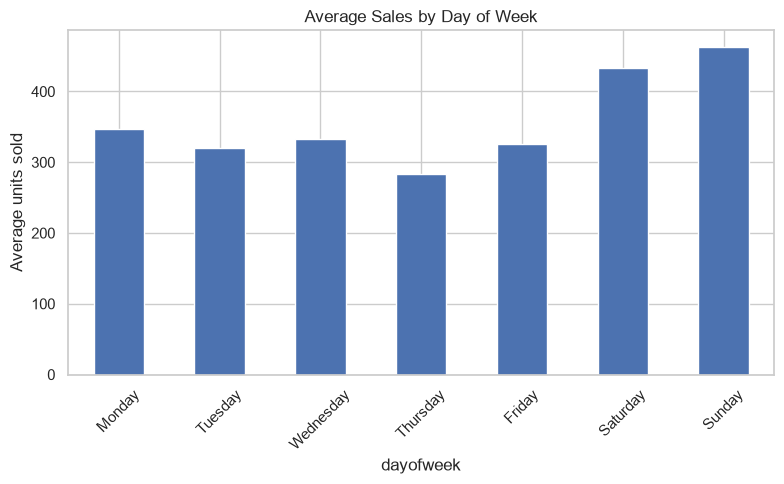

In [72]:
def plot_dayofweek_seasonality(data):
    temp = data.copy()
    temp["dayofweek"] = temp["date"].dt.day_name()
    order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    avg = temp.groupby("dayofweek", observed=True)["sales"].mean().reindex(order)
    plt.figure(figsize=(8, 5))
    avg.plot(kind="bar", color="#4C72B0")
    plt.title("Average Sales by Day of Week")
    plt.ylabel("Average units sold")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/08_dayofweek_seasonality.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_dayofweek_seasonality(train)

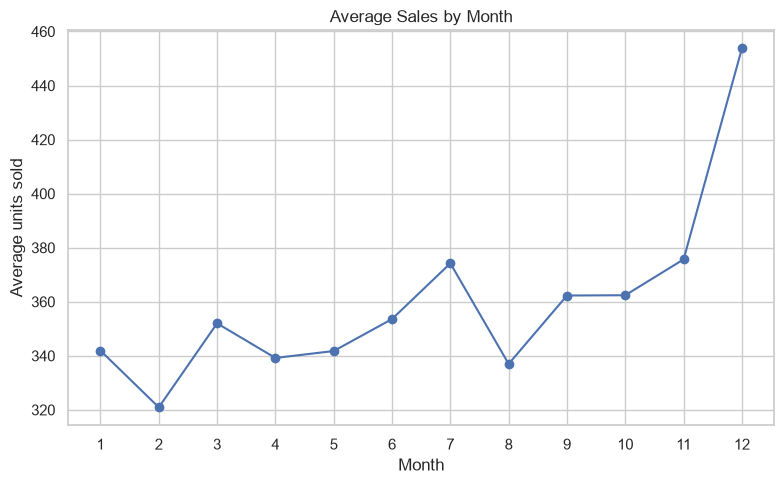

In [73]:
def plot_monthly_seasonality(data):
    temp = data.copy()
    temp["month"] = temp["date"].dt.month
    avg = temp.groupby("month", observed=True)["sales"].mean()
    plt.figure(figsize=(8, 5))
    avg.plot(kind="line", marker="o", color="#4C72B0")
    plt.title("Average Sales by Month")
    plt.xlabel("Month")
    plt.ylabel("Average units sold")
    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/09_monthly_seasonality.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_monthly_seasonality(train)

### Sales by city

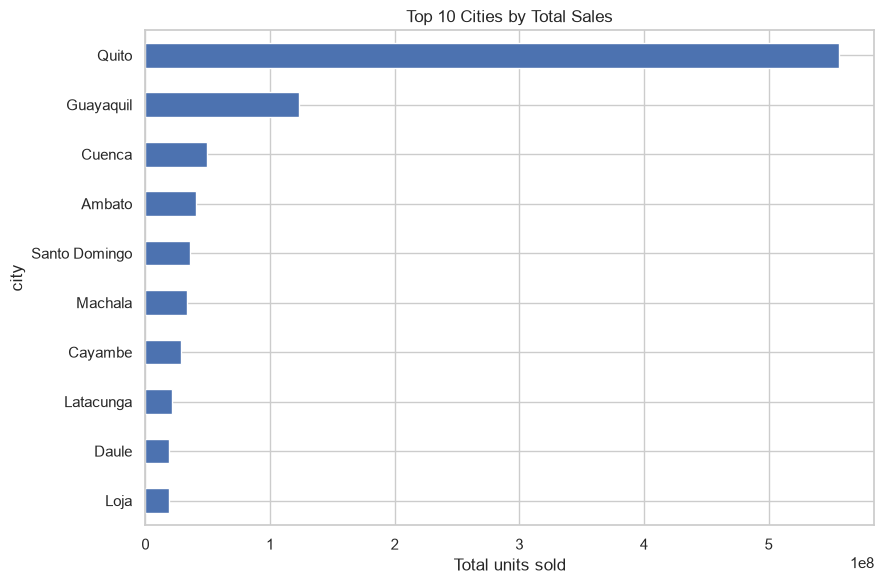

In [74]:
def plot_sales_by_city(data, stores_df, top_n=10):
    merged = data.merge(stores_df[["store_nbr", "city"]], on="store_nbr", how="left")
    by_city = merged.groupby("city", observed=True)["sales"].sum().sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(9, 6))
    by_city.plot(kind="barh", color="#4C72B0")
    plt.gca().invert_yaxis()
    plt.title(f"Top {top_n} Cities by Total Sales")
    plt.xlabel("Total units sold")
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/10_sales_by_city.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_sales_by_city(train, stores)

### Sales by store cluster

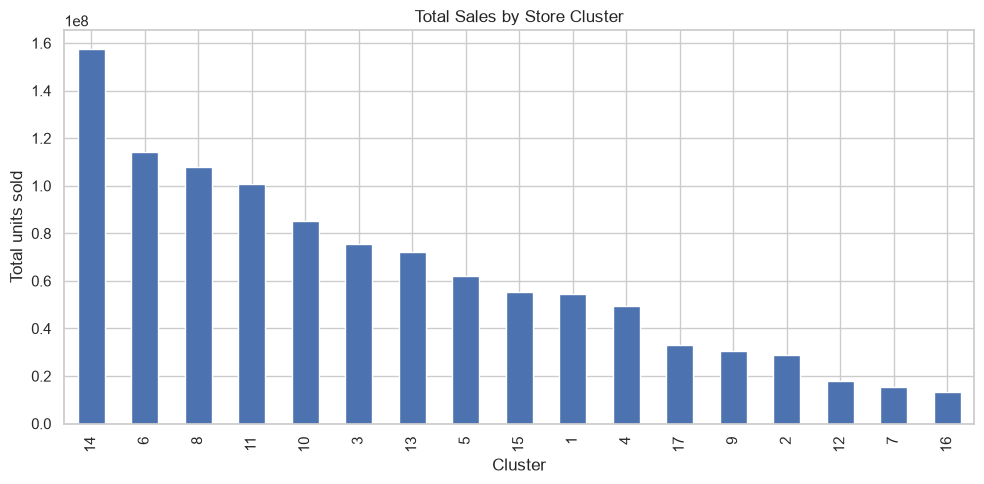

In [75]:
def plot_sales_by_cluster(data, stores_df):
    merged = data.merge(stores_df[["store_nbr", "cluster"]], on="store_nbr", how="left")
    by_cluster = merged.groupby("cluster", observed=True)["sales"].sum().sort_values(ascending=False)
    plt.figure(figsize=(10, 5))
    by_cluster.plot(kind="bar", color="#4C72B0")
    plt.title("Total Sales by Store Cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Total units sold")
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/11_sales_by_cluster.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_sales_by_cluster(train, stores)

### Holiday/event effect on sales (descriptive cut)

A quick descriptive comparison only - this uses every date that appears anywhere in `holidays_events.csv`, not the leakage-safe transferred-flag resolution built in Process below. Treat this as an EDA sanity check, not a modeling feature.

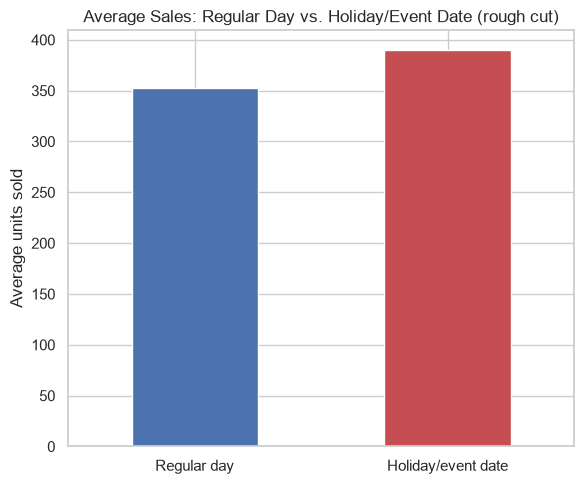

Regular day           352.159180
Holiday/event date    389.692139
Name: sales, dtype: float32


In [76]:
def plot_holiday_effect(data, holidays_df):
    any_holiday_dates = set(holidays_df["date"])
    temp = data.copy()
    temp["is_any_holiday_date"] = temp["date"].isin(any_holiday_dates)
    avg = temp.groupby("is_any_holiday_date")["sales"].mean()
    avg.index = ["Regular day", "Holiday/event date"]
    plt.figure(figsize=(6, 5))
    avg.plot(kind="bar", color=["#4C72B0", "#C44E52"])
    plt.title("Average Sales: Regular Day vs. Holiday/Event Date (rough cut)")
    plt.ylabel("Average units sold")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/12_holiday_effect.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(avg)


plot_holiday_effect(train, holidays)

### Transactions vs. sales

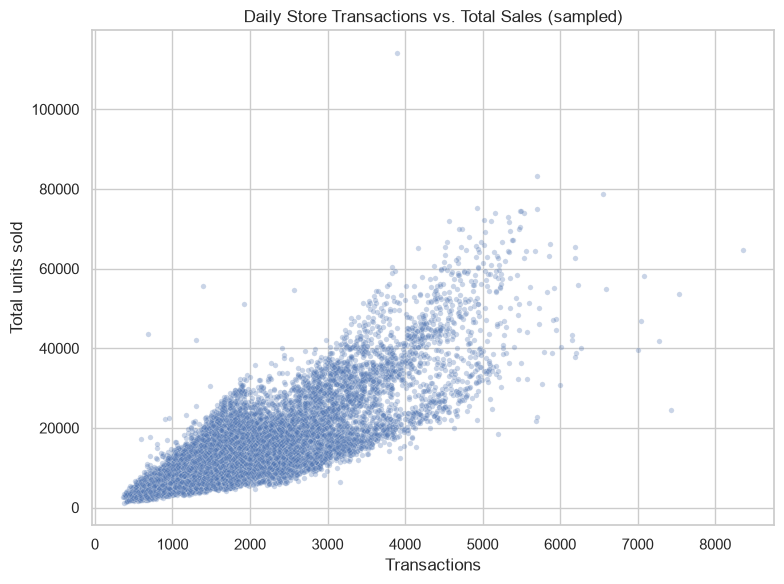

Correlation (transactions, sales): 0.834


In [77]:
def plot_transactions_vs_sales(data, transactions_df, sample_size=20_000):
    daily_sales = data.groupby(["date", "store_nbr"], observed=True)["sales"].sum().reset_index()
    merged = daily_sales.merge(transactions_df, on=["date", "store_nbr"], how="inner")
    if len(merged) > sample_size:
        merged = merged.sample(sample_size, random_state=42)
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=merged, x="transactions", y="sales", alpha=0.3, s=15, color="#4C72B0")
    plt.title("Daily Store Transactions vs. Total Sales (sampled)")
    plt.xlabel("Transactions")
    plt.ylabel("Total units sold")
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/13_transactions_vs_sales_scatter.png", dpi=150, bbox_inches="tight")
    plt.show()
    corr = merged["transactions"].corr(merged["sales"])
    print(f"Correlation (transactions, sales): {corr:.3f}")


plot_transactions_vs_sales(train, transactions)

### Correlation snapshot (raw daily aggregates, before any feature engineering)

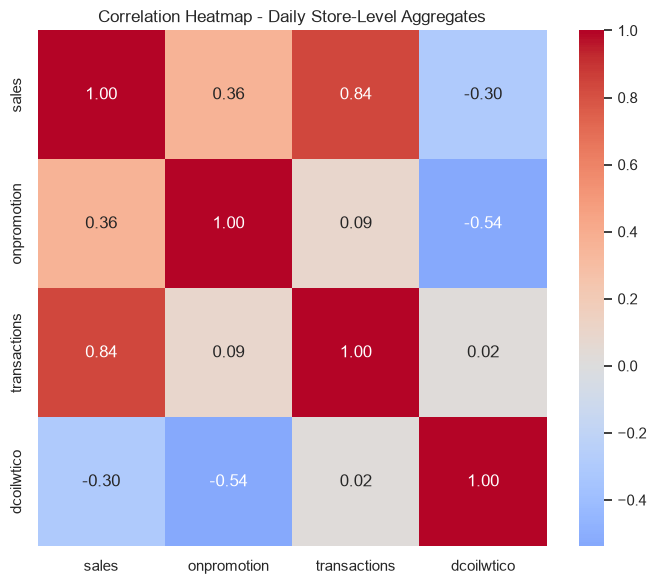

In [78]:
def plot_raw_correlation_heatmap(data, transactions_df, oil_df):
    daily = data.groupby(["date", "store_nbr"], observed=True).agg(
        sales=("sales", "sum"), onpromotion=("onpromotion", "sum")
    ).reset_index()
    daily = daily.merge(transactions_df, on=["date", "store_nbr"], how="left")
    daily = daily.merge(oil_df, on="date", how="left")
    corr_cols = ["sales", "onpromotion", "transactions", "dcoilwtico"]
    plt.figure(figsize=(7, 6))
    sns.heatmap(daily[corr_cols].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
    plt.title("Correlation Heatmap - Daily Store-Level Aggregates")
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/14_raw_correlation_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_raw_correlation_heatmap(train, transactions, oil)

### Series completeness, visualized

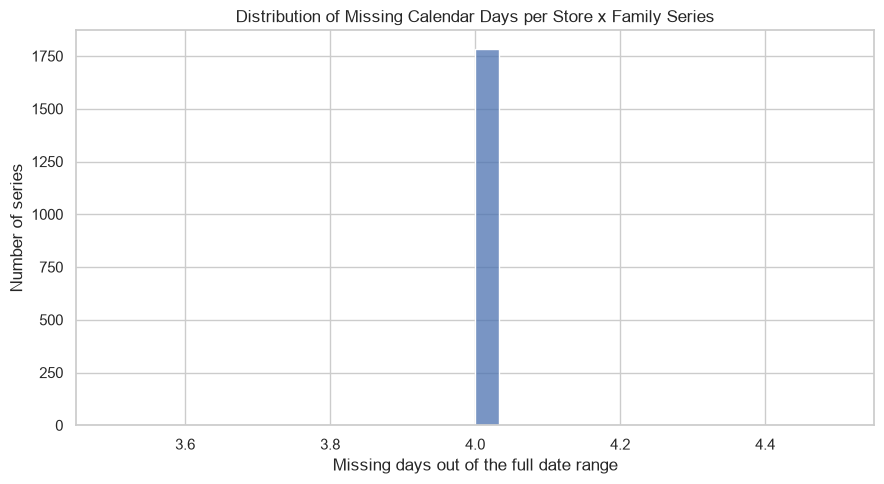

In [79]:
def plot_missing_days_distribution(missing_series):
    plt.figure(figsize=(9, 5))
    sns.histplot(missing_series, bins=30, color="#4C72B0")
    plt.title("Distribution of Missing Calendar Days per Store x Family Series")
    plt.xlabel("Missing days out of the full date range")
    plt.ylabel("Number of series")
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/15_missing_days_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_missing_days_distribution(missing_per_series)

## 3. Process - Clean and Engineer Features

### Resolving the transferred-holiday flag

This is the documented gotcha in this dataset: a holiday marked `transferred=True` did NOT happen on its listed date - it moved to a different date, which shows up as its own row with `type == "Transfer"`. `type == "Work Day"` means a normally non-working day was turned INTO a working day (compensating for a bridge elsewhere), so it should not be flagged as a holiday either.


In [80]:
def build_holiday_flag(holidays_df):
    """Returns the set of dates that are actually non-working/holiday days,
    with the transferred-flag logic resolved correctly."""
    df = holidays_df.copy()

    observed = df[~df["transferred"]]

    holiday_dates = set(observed.loc[observed["type"] != "Work Day", "date"])
    return holiday_dates


national_holidays = holidays[holidays["locale"] == "National"]
holiday_dates = build_holiday_flag(national_holidays)
print(f"Resolved {len(holiday_dates)} national holiday/non-working dates.")

Resolved 155 national holiday/non-working dates.


### Merging everything onto the sales table

In [81]:
series_index = pd.MultiIndex.from_product(
    [train["store_nbr"].unique(), train["family"].cat.categories, full_date_range],
    names=["store_nbr", "family", "date"],
)
data = train.set_index(["store_nbr", "family", "date"]).reindex(series_index).reset_index()
data["sales"] = data["sales"].fillna(0).astype("float32")
data["onpromotion"] = data["onpromotion"].fillna(0).astype("int32")

data = data.merge(stores, on="store_nbr", how="left")

oil_filled = oil.set_index("date").reindex(full_date_range)["dcoilwtico"].interpolate().ffill().bfill()
oil_filled = oil_filled.rename("oil_price").reset_index().rename(columns={"index": "date"})
data = data.merge(oil_filled, on="date", how="left")

data["is_holiday"] = data["date"].isin(holiday_dates).astype("int8")

transactions_lag1 = transactions.assign(date=transactions["date"] + pd.Timedelta(days=1))
transactions_lag1 = transactions_lag1.rename(columns={"transactions": "transactions_lag_1"})
data = data.merge(transactions_lag1, on=["date", "store_nbr"], how="left")

fill_cutoff = train["date"].max() - pd.Timedelta(days=29)   
store_median = transactions[transactions["date"] < fill_cutoff].groupby("store_nbr")["transactions"].median()
data["transactions_lag_1"] = data["transactions_lag_1"].fillna(data["store_nbr"].map(store_median))
data["transactions_lag_1"] = data["transactions_lag_1"].fillna(transactions["transactions"].median())

print(f"Merged shape: {data.shape}")
data.head()

Merged shape: (3008016, 13)


,store_nbr,family,date,id,sales,onpromotion,city,state,type,cluster,oil_price,is_holiday,transactions_lag_1
0,1,AUTOMOTIVE,2013-01-01,0.0,0.0,0,Quito,Pichincha,D,13,93.139999,1,1746.5
1,1,AUTOMOTIVE,2013-01-02,1782.0,2.0,0,Quito,Pichincha,D,13,93.139999,0,1746.5
2,1,AUTOMOTIVE,2013-01-03,3564.0,3.0,0,Quito,Pichincha,D,13,92.970001,0,2111.0
3,1,AUTOMOTIVE,2013-01-04,5346.0,3.0,0,Quito,Pichincha,D,13,93.120003,0,1833.0
4,1,AUTOMOTIVE,2013-01-05,7128.0,5.0,0,Quito,Pichincha,D,13,93.146667,0,1863.0


### Lag, rolling, and calendar features (computed per store x family to avoid leaking across series)

In [82]:
data = data.sort_values(["store_nbr", "family", "date"])
grp = data.groupby(["store_nbr", "family"], observed=True)["sales"]

for lag in [7, 14, 28]:
    data[f"sales_lag_{lag}"] = grp.shift(lag)

shifted = grp.shift(1)
data["rolling_mean_7"] = shifted.groupby([data["store_nbr"], data["family"]]).transform(
    lambda s: s.rolling(7, min_periods=1).mean()
)
data["rolling_mean_28"] = shifted.groupby([data["store_nbr"], data["family"]]).transform(
    lambda s: s.rolling(28, min_periods=1).mean()
)
data["rolling_std_7"] = shifted.groupby([data["store_nbr"], data["family"]]).transform(
    lambda s: s.rolling(7, min_periods=1).std()
)

data["dayofweek"] = data["date"].dt.dayofweek
data["month"] = data["date"].dt.month
data["day"] = data["date"].dt.day
data["is_weekend"] = data["dayofweek"].isin([5, 6]).astype("int8")
data["any_promotion"] = (data["onpromotion"] > 0).astype("int8")
data["oil_price_change"] = data["oil_price"].diff().fillna(0)

before = len(data)
data = data.dropna(subset=["sales_lag_28"]).reset_index(drop=True)
print(f"Dropped {before - len(data):,} warm-up rows; {len(data):,} rows remain.")

Dropped 49,896 warm-up rows; 2,958,120 rows remain.


### One-hot encoding + chronological split (never a random shuffle for time series)

In [83]:
data = pd.get_dummies(data, columns=["family", "type"], prefix=["family", "store_type"], dtype="int8")

feature_cols_base = [
    "onpromotion", "any_promotion", "is_holiday", "cluster",
    "sales_lag_7", "sales_lag_14", "sales_lag_28",
    "rolling_mean_7", "rolling_mean_28", "rolling_std_7",
    "dayofweek", "month", "day", "is_weekend", "transactions_lag_1",
] + [c for c in data.columns if c.startswith("family_") or c.startswith("store_type_")]

feature_cols_with_oil = feature_cols_base + ["oil_price", "oil_price_change"]

TEST_DAYS = 15
max_date = data["date"].max()
test_start = max_date - pd.Timedelta(days=TEST_DAYS - 1)
val_start = test_start - pd.Timedelta(days=TEST_DAYS)

train_df = data[data["date"] < val_start]
val_df = data[(data["date"] >= val_start) & (data["date"] < test_start)]
test_df = data[data["date"] >= test_start]

for name, d in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"{name}: {d['date'].min().date()} to {d['date'].max().date()}, {len(d):,} rows")

Train: 2013-01-29 to 2017-07-16, 2,904,660 rows
Validation: 2017-07-17 to 2017-07-31, 26,730 rows
Test: 2017-08-01 to 2017-08-15, 26,730 rows


## 4. Analyze - Model Building and Comparison

Following the experiment matrix from the plan: naive baselines, ARIMA and Prophet fit per-series on a handful of representative high-volume series, then global Random Forest / XGBoost / LSTM models trained across all series at once.


In [84]:
results = []

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mape(y_true, y_pred):
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

def wape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return float(np.sum(np.abs(y_true - y_pred)) / denom * 100)

def forecast_bias(y_true, y_pred):
    denom = np.sum(y_true)
    if denom == 0:
        return np.nan
    return float((np.sum(y_pred) - denom) / denom * 100)

def evaluate_forecast(name, y_true, y_pred, record=True):
    y_true = np.asarray(y_true, dtype="float64")
    y_pred = np.asarray(y_pred, dtype="float64")
    metrics = {
        "Experiment": name,
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
        "WAPE_%": wape(y_true, y_pred),
        "Bias_%": forecast_bias(y_true, y_pred),
    }
    if record:
        results.append(metrics)
    print(f"--- {name} ---")
    print(f"RMSE: {metrics['RMSE']:.3f}  MAPE: {metrics['MAPE_%']:.2f}%  "
          f"WAPE: {metrics['WAPE_%']:.2f}%  Bias: {metrics['Bias_%']:+.2f}%")
    return metrics

### Picking representative series

ARIMA and Prophet are fit one series at a time, which doesn't scale to ~1,782 series in a first pass. Following the plan's recommended role, they're fit on the top 5 highest-volume store x family series, and every model (including the global ones) is compared on this same subset for a fair, apples-to-apples table - the global models are *also* evaluated on the full test set separately, further down. Note the horizon difference: ARIMA and Prophet forecast the whole window from one origin (multi-step), while the naive, tree and LSTM models use actuals through the previous day (one-step).

In [85]:
series_totals = train.groupby(["store_nbr", "family"], observed=True)["sales"].sum().sort_values(ascending=False)
representative_series = list(series_totals.head(5).index)
print("Representative series (store_nbr, family):")
for s in representative_series:
    print(f"  {s}  (total sales: {series_totals[s]:,.0f})")
rep_mask = np.zeros(len(test_df), dtype=bool)
for s, f in representative_series:
    rep_mask |= ((test_df["store_nbr"] == s) & (test_df[f"family_{f}"] == 1)).values
print(f"Representative-series rows in the test window: {rep_mask.sum()} "
      f"({len(representative_series)} series x {TEST_DAYS} days)")


Representative series (store_nbr, family):
  (44, 'GROCERY I')  (total sales: 16,386,055)
  (45, 'GROCERY I')  (total sales: 16,349,751)
  (47, 'GROCERY I')  (total sales: 15,514,528)
  (46, 'GROCERY I')  (total sales: 14,342,262)
  (44, 'BEVERAGES')  (total sales: 13,417,859)
Representative-series rows in the test window: 75 (5 series x 15 days)


### Experiment 1 - Naive & seasonal-naive baseline

In [86]:
naive_true, naive_pred, snaive_pred = [], [], []

for store_nbr, family in representative_series:
    series = train[(train["store_nbr"] == store_nbr) & (train["family"] == family)].sort_values("date")
    series = series.set_index("date")["sales"]

    test_slice = series.loc[test_start:max_date]
    naive_forecast = series.shift(1).loc[test_start:max_date]          
    seasonal_naive_forecast = series.shift(7).loc[test_start:max_date]  

    naive_true.extend(test_slice.values)
    naive_pred.extend(naive_forecast.values)
    snaive_pred.extend(seasonal_naive_forecast.values)

naive_true = np.array(naive_true)
naive_pred = np.nan_to_num(np.array(naive_pred))
snaive_pred = np.nan_to_num(np.array(snaive_pred))

evaluate_forecast("1a. Naive (yesterday's value)", naive_true, naive_pred)
evaluate_forecast("1b. Seasonal-naive (same weekday last week)", naive_true, snaive_pred)

--- 1a. Naive (yesterday's value) ---
RMSE: 2063.516  MAPE: 16.22%  WAPE: 15.77%  Bias: +1.93%
--- 1b. Seasonal-naive (same weekday last week) ---
RMSE: 2503.252  MAPE: 21.75%  WAPE: 21.14%  Bias: +8.66%


{'Experiment': '1b. Seasonal-naive (same weekday last week)',
 'RMSE': 2503.2524443211873,
 'MAPE_%': 21.751653873736483,
 'WAPE_%': 21.14225220212001,
 'Bias_%': 8.660812443165623}

### Experiment 2 - ARIMA (SARIMAX with weekly seasonality) per representative series

In [87]:
arima_true, arima_pred = [], []

for store_nbr, family in representative_series:
    series = train[(train["store_nbr"] == store_nbr) & (train["family"] == family)].sort_values("date")
    series = series.set_index("date")["sales"].asfreq("D").fillna(0)

    train_part = series.loc[:val_start - pd.Timedelta(days=1)]
    test_part = series.loc[test_start:max_date]

    model = SARIMAX(
        train_part, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False, enforce_invertibility=False,
    )
    fitted = model.fit(disp=False)
    n_steps = (max_date - train_part.index[-1]).days
    forecast = fitted.forecast(steps=n_steps).loc[test_start:max_date]
    assert len(forecast) == len(test_part)

    arima_true.extend(test_part.values)
    arima_pred.extend(forecast.values)

evaluate_forecast("2. ARIMA (SARIMAX, weekly seasonal)", np.array(arima_true), np.array(arima_pred))

--- 2. ARIMA (SARIMAX, weekly seasonal) ---
RMSE: 2348.796  MAPE: 19.40%  WAPE: 18.83%  Bias: +12.71%


{'Experiment': '2. ARIMA (SARIMAX, weekly seasonal)',
 'RMSE': 2348.796054347658,
 'MAPE_%': 19.400511378862547,
 'WAPE_%': 18.830058542681584,
 'Bias_%': 12.709313282453504}

### Experiment 3 - Prophet (with holiday + promotion regressors) per representative series

In [88]:
prophet_holidays_df = pd.DataFrame({"ds": sorted(holiday_dates), "holiday": "national_holiday"})

prophet_true, prophet_pred = [], []

for store_nbr, family in representative_series:
    series = train[(train["store_nbr"] == store_nbr) & (train["family"] == family)].sort_values("date")
    prophet_df = series.rename(columns={"date": "ds", "sales": "y"})[["ds", "y", "onpromotion"]]

    train_part = prophet_df[prophet_df["ds"] < val_start]
    test_part = prophet_df[prophet_df["ds"] >= test_start]

    model = Prophet(holidays=prophet_holidays_df, weekly_seasonality=True, yearly_seasonality=True)
    model.add_regressor("onpromotion")
    model.fit(train_part)

    forecast = model.predict(test_part[["ds", "onpromotion"]])

    prophet_true.extend(test_part["y"].values)
    prophet_pred.extend(forecast["yhat"].values)

evaluate_forecast("3. Prophet (holiday + promotion regressors)", np.array(prophet_true), np.array(prophet_pred))

--- 3. Prophet (holiday + promotion regressors) ---
RMSE: 2031.169  MAPE: 17.07%  WAPE: 16.49%  Bias: +9.56%


{'Experiment': '3. Prophet (holiday + promotion regressors)',
 'RMSE': 2031.1694183254174,
 'MAPE_%': 17.073822863981484,
 'WAPE_%': 16.49278997512517,
 'Bias_%': 9.561785627151725}

### Experiments 4-6 - Global Random Forest & XGBoost

In [89]:
X_train_full = train_df[feature_cols_base]
y_train_full = train_df["sales"]
X_val_full = val_df[feature_cols_base]
X_test_full = test_df[feature_cols_base]
y_val_full = val_df["sales"]
y_test_full = test_df["sales"]

rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_full, y_train_full)
rf_pred_val = rf.predict(X_val_full)
rf_pred_full = rf.predict(X_test_full)

evaluate_forecast("4. Random Forest (global, lags+calendar+promo+holiday)", y_test_full.values[rep_mask], rf_pred_full[rep_mask])

--- 4. Random Forest (global, lags+calendar+promo+holiday) ---
RMSE: 1596.407  MAPE: 12.32%  WAPE: 12.26%  Bias: +9.31%


{'Experiment': '4. Random Forest (global, lags+calendar+promo+holiday)',
 'RMSE': 1596.4065333273688,
 'MAPE_%': 12.319042151878106,
 'WAPE_%': 12.257454139560695,
 'Bias_%': 9.31248790994691}

In [90]:
xgb_model = xgb.XGBRegressor(
    n_estimators=400, max_depth=8, learning_rate=0.05,
    random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_model.fit(X_train_full, y_train_full)
xgb_pred_val = xgb_model.predict(X_val_full)
xgb_pred_full = xgb_model.predict(X_test_full)

evaluate_forecast("5. XGBoost (global, lags+calendar+promo+holiday)", y_test_full.values[rep_mask], xgb_pred_full[rep_mask])

--- 5. XGBoost (global, lags+calendar+promo+holiday) ---
RMSE: 857.096  MAPE: 7.05%  WAPE: 6.86%  Bias: +2.24%


{'Experiment': '5. XGBoost (global, lags+calendar+promo+holiday)',
 'RMSE': 857.0955177461143,
 'MAPE_%': 7.053487971768489,
 'WAPE_%': 6.856026026433075,
 'Bias_%': 2.2402515923168407}

In [91]:
X_train_oil = train_df[feature_cols_with_oil]
X_val_oil = val_df[feature_cols_with_oil]
X_test_oil = test_df[feature_cols_with_oil]

xgb_oil_model = xgb.XGBRegressor(
    n_estimators=400, max_depth=8, learning_rate=0.05,
    random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_oil_model.fit(X_train_oil, y_train_full)
xgb_oil_pred_val = xgb_oil_model.predict(X_val_oil)
xgb_oil_pred_full = xgb_oil_model.predict(X_test_oil)

evaluate_forecast("6. XGBoost + oil price", y_test_full.values[rep_mask], xgb_oil_pred_full[rep_mask])

--- 6. XGBoost + oil price ---
RMSE: 1301.326  MAPE: 9.70%  WAPE: 9.77%  Bias: +5.65%


{'Experiment': '6. XGBoost + oil price',
 'RMSE': 1301.3262633460424,
 'MAPE_%': 9.704309074250062,
 'WAPE_%': 9.770905971235868,
 'Bias_%': 5.6460983704439185}

### Experiment 7 - Global LSTM with store/family embeddings

Note on scope: building lookback-window sequences for all ~1,782 series would be the full production version. To keep training time reasonable here, the sequence dataset below is built from a sample of 50 series rather than all of them - the same code scales to the full set by widening `N_SAMPLE_SERIES`. The 5 representative series are always included in the sample so the LSTM can be scored on the same rows as every other experiment.

The LSTM standardizes sales and promotion counts separately for each series using training-period statistics only. It receives a 28-day sequence of scaled sales, scaled promotions, calendar and holiday features, then predicts the next scaled sales value. An explicit chronological validation window is used for early stopping; predictions are inverse-transformed and clipped at zero before scoring. The 50-series sample remains an internship-scope benchmark rather than a deployable candidate.

In [92]:
N_SAMPLE_SERIES = 50
LOOKBACK = 28

all_series_ids = list(train.groupby(["store_nbr", "family"], observed=True).groups.keys())
rng = np.random.RandomState(RANDOM_STATE)
rep_set = set(representative_series)
other_series = [s for s in all_series_ids if s not in rep_set]
extra_idx = rng.choice(len(other_series), size=N_SAMPLE_SERIES - len(representative_series), replace=False)
sampled_series = list(representative_series) + [other_series[i] for i in extra_idx]

store_ids = sorted(train["store_nbr"].unique())
family_ids = sorted(train["family"].unique())
store_to_idx = {s: i for i, s in enumerate(store_ids)}
family_to_idx = {f: i for i, f in enumerate(family_ids)}

LSTM_SEQUENCE_FEATURES = ["scaled_sales", "scaled_promotion", "dayofweek", "month", "is_weekend", "is_holiday"]

def build_lstm_sequences(store_nbr, family, series_df, split_start, split_end, sales_mean, sales_std, promo_mean, promo_std):
    daily = series_df.set_index("date").asfreq("D")
    dates = daily.index
    sales = daily["sales"].fillna(0).to_numpy(dtype="float32")
    promotions = daily["onpromotion"].fillna(0).to_numpy(dtype="float32")
    holidays = daily["is_holiday"].fillna(0).to_numpy(dtype="float32")

    sequence_features = np.column_stack([
        (sales - sales_mean) / sales_std,
        (promotions - promo_mean) / promo_std,
        dates.dayofweek / 6.0,
        dates.month / 12.0,
        (dates.dayofweek >= 5).astype("float32"),
        holidays,
    ]).astype("float32")

    X_seq, X_store, X_family, y_scaled, y_actual = [], [], [], [], []
    for i in range(LOOKBACK, len(dates)):
        current_date = dates[i]
        if not (split_start <= current_date < split_end):
            continue
        X_seq.append(sequence_features[i - LOOKBACK:i])
        X_store.append(store_to_idx[store_nbr])
        X_family.append(family_to_idx[family])
        y_scaled.append((sales[i] - sales_mean) / sales_std)
        y_actual.append(sales[i])
    return X_seq, X_store, X_family, y_scaled, y_actual

lstm_X_seq_train, lstm_X_store_train, lstm_X_family_train, lstm_y_train = [], [], [], []
lstm_X_seq_val, lstm_X_store_val, lstm_X_family_val, lstm_y_val = [], [], [], []
lstm_X_seq_test, lstm_X_store_test, lstm_X_family_test, lstm_y_test = [], [], [], []
lstm_test_means, lstm_test_stds = [], []
lstm_test_series = []  

for store_nbr, family in sampled_series:
    family_col = f"family_{family}"
    series_df = data[(data["store_nbr"] == store_nbr) & (data[family_col] == 1)]
    scale_df = series_df[series_df["date"] < val_start]
    sales_mean = scale_df["sales"].mean()
    sales_std = max(scale_df["sales"].std(), 1.0)
    promo_mean = scale_df["onpromotion"].mean()
    promo_std = max(scale_df["onpromotion"].std(), 1.0)

    xs, xst, xf, y_scaled, _ = build_lstm_sequences(store_nbr, family, series_df, series_df["date"].min(), val_start, sales_mean, sales_std, promo_mean, promo_std)
    lstm_X_seq_train.extend(xs); lstm_X_store_train.extend(xst); lstm_X_family_train.extend(xf); lstm_y_train.extend(y_scaled)

    xs, xst, xf, y_scaled, _ = build_lstm_sequences(store_nbr, family, series_df, val_start, test_start, sales_mean, sales_std, promo_mean, promo_std)
    lstm_X_seq_val.extend(xs); lstm_X_store_val.extend(xst); lstm_X_family_val.extend(xf); lstm_y_val.extend(y_scaled)

    xs, xst, xf, _, y_actual = build_lstm_sequences(store_nbr, family, series_df, test_start, max_date + pd.Timedelta(days=1), sales_mean, sales_std, promo_mean, promo_std)
    lstm_X_seq_test.extend(xs); lstm_X_store_test.extend(xst); lstm_X_family_test.extend(xf); lstm_y_test.extend(y_actual)
    lstm_test_means.extend([sales_mean] * len(y_actual)); lstm_test_stds.extend([sales_std] * len(y_actual))
    lstm_test_series.extend([(store_nbr, family)] * len(y_actual))

lstm_X_seq_train = np.array(lstm_X_seq_train)
lstm_X_seq_val = np.array(lstm_X_seq_val)
lstm_X_seq_test = np.array(lstm_X_seq_test)
lstm_X_store_train, lstm_X_family_train = np.array(lstm_X_store_train), np.array(lstm_X_family_train)
lstm_X_store_val, lstm_X_family_val = np.array(lstm_X_store_val), np.array(lstm_X_family_val)
lstm_X_store_test, lstm_X_family_test = np.array(lstm_X_store_test), np.array(lstm_X_family_test)
lstm_y_train, lstm_y_val, lstm_y_test = np.array(lstm_y_train), np.array(lstm_y_val), np.array(lstm_y_test)
lstm_test_means, lstm_test_stds = np.array(lstm_test_means), np.array(lstm_test_stds)

print(f"LSTM train sequences: {lstm_X_seq_train.shape}, validation sequences: {lstm_X_seq_val.shape}, test sequences: {lstm_X_seq_test.shape}")

LSTM train sequences: (80100, 28, 6), validation sequences: (750, 28, 6), test sequences: (750, 28, 6)


In [93]:
seq_input = layers.Input(shape=(LOOKBACK, len(LSTM_SEQUENCE_FEATURES)), name="sales_sequence")
store_input = layers.Input(shape=(1,), name="store_id")
family_input = layers.Input(shape=(1,), name="family_id")

store_emb = layers.Embedding(len(store_ids), 4)(store_input)
store_emb = layers.Flatten()(store_emb)
family_emb = layers.Embedding(len(family_ids), 4)(family_input)
family_emb = layers.Flatten()(family_emb)

lstm_out = layers.LSTM(32)(seq_input)

combined = layers.Concatenate()([lstm_out, store_emb, family_emb])
dense = layers.Dense(16, activation="relu")(combined)
output = layers.Dense(1, activation="linear")(dense)

lstm_model = keras.Model(inputs=[seq_input, store_input, family_input], outputs=output)
lstm_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss=keras.losses.Huber())

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = lstm_model.fit(
    [lstm_X_seq_train, lstm_X_store_train, lstm_X_family_train], lstm_y_train,
    validation_data=([lstm_X_seq_val, lstm_X_store_val, lstm_X_family_val], lstm_y_val),
    epochs=30, batch_size=64, callbacks=[early_stop], verbose=1, shuffle=True,
)

lstm_pred_scaled = lstm_model.predict([lstm_X_seq_test, lstm_X_store_test, lstm_X_family_test], verbose=0).flatten()
lstm_pred = np.maximum(0, lstm_pred_scaled * lstm_test_stds + lstm_test_means)
lstm_rep_mask = np.array([s in rep_set for s in lstm_test_series])
evaluate_forecast("7. LSTM (global, store/family embeddings, 50-series sample)",
                  lstm_y_test[lstm_rep_mask], lstm_pred[lstm_rep_mask])

_ = evaluate_forecast("7. LSTM on its full 50-series sample (reference only)", lstm_y_test, lstm_pred, record=False)

Epoch 1/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 0.1937 - val_loss: 0.2077
Epoch 2/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 0.1595 - val_loss: 0.1993
Epoch 3/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.1534 - val_loss: 0.2008
Epoch 4/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 0.1498 - val_loss: 0.1996
Epoch 5/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.1472 - val_loss: 0.1986
Epoch 6/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.1449 - val_loss: 0.1960
Epoch 7/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.1432 - val_loss: 0.1936
Epoch 8/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.1417 - val_loss: 0.1916
Epoch 9/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.1403 - val_loss: 0.1908
Epoch 10/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.1391 - val_loss: 0.1908
Epoch 11/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.1380 - val_loss: 0.1908
Epoch 12

### Experiment matrix - representative-series comparison

All 9 experiments are scored on the same 5 representative series (75 test rows). ARIMA and Prophet forecast multi-step from a single origin; the other models are one-step-ahead.


In [94]:
results_df = pd.DataFrame(results).sort_values("WAPE_%").reset_index(drop=True)
results_df

,Experiment,RMSE,MAPE_%,WAPE_%,Bias_%
0,"5. XGBoost (global, lags+calendar+promo+holiday)",857.095518,7.053488,6.856026,2.240252
1,6. XGBoost + oil price,1301.326263,9.704309,9.770906,5.646098
2,"4. Random Forest (global, lags+calendar+promo+...",1596.406533,12.319042,12.257454,9.312488
3,"7. LSTM (global, store/family embeddings, 50-s...",1518.113344,11.869016,12.313734,4.941232
4,1a. Naive (yesterday's value),2063.516491,16.223227,15.774780,1.933115
5,3. Prophet (holiday + promotion regressors),2031.169418,17.073823,16.492790,9.561786
6,"2. ARIMA (SARIMAX, weekly seasonal)",2348.796054,19.400511,18.830059,12.709313
7,1b. Seasonal-naive (same weekday last week),2503.252444,21.751654,21.142252,8.660812


### Global aggregate performance (Random Forest, XGBoost, XGBoost+oil) across the full test set - all series, not just the 5 representative ones

In [95]:
global_results = []

def evaluate_global(name, y_true, y_pred):
    metrics = {
        "Experiment": name,
        "RMSE": rmse(y_true, y_pred),
        "WAPE_%": wape(y_true, y_pred),
        "Bias_%": forecast_bias(y_true, y_pred),
    }
    global_results.append(metrics)
    return metrics

evaluate_global("4. Random Forest (global, lags+calendar+promo+holiday)", y_test_full.values, rf_pred_full)
evaluate_global("5. XGBoost (global, lags+calendar+promo+holiday)", y_test_full.values, xgb_pred_full)
evaluate_global("6. XGBoost + oil price", y_test_full.values, xgb_oil_pred_full)

global_results_df = pd.DataFrame(global_results).sort_values("WAPE_%").reset_index(drop=True)
global_results_df


,Experiment,RMSE,WAPE_%,Bias_%
0,"5. XGBoost (global, lags+calendar+promo+holiday)",198.281296,12.934275,2.982212
1,6. XGBoost + oil price,223.054947,14.335330,5.269798
2,"4. Random Forest (global, lags+calendar+promo+...",238.516635,15.309521,5.088744


### Hyperparameter tuning on the strongest candidate

In [96]:
param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [6, 8, 10, 12],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
}

cv_dates = np.sort(train_df["date"].unique())
fold_size = len(cv_dates) // 4
date_folds = []
for fold in range(1, 4):
    fold_train_dates = cv_dates[:fold * fold_size]
    fold_val_dates = cv_dates[fold * fold_size:(fold + 1) * fold_size]
    train_idx = np.flatnonzero(train_df["date"].isin(fold_train_dates).to_numpy())
    val_idx = np.flatnonzero(train_df["date"].isin(fold_val_dates).to_numpy())
    date_folds.append((train_idx, val_idx))

xgb_base = xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)

search = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist, n_iter=15, scoring="neg_root_mean_squared_error",
    cv=date_folds, random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
search.fit(X_train_full, y_train_full)

print("Best params:", search.best_params_)

best_model = search.best_estimator_
best_pred_val = best_model.predict(X_val_full)
best_pred_full = best_model.predict(X_test_full)

evaluate_forecast("8. XGBoost (tuned, global)", y_test_full.values[rep_mask], best_pred_full[rep_mask])
evaluate_global("8. XGBoost (tuned, global)", y_test_full.values, best_pred_full)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
--- 8. XGBoost (tuned, global) ---
RMSE: 1120.323  MAPE: 8.76%  WAPE: 8.62%  Bias: +3.77%


{'Experiment': '8. XGBoost (tuned, global)',
 'RMSE': 214.750732421875,
 'WAPE_%': 14.253250122070312,
 'Bias_%': 4.314952850341797}

### Final model selection

In [97]:
final_results_df = pd.DataFrame(results).sort_values("WAPE_%").reset_index(drop=True)
global_results_df = pd.DataFrame(global_results).sort_values("WAPE_%").reset_index(drop=True)

print("Representative-series comparison (same 5 series, all experiments):")
print(final_results_df)
print("\nFull test set (deployable global models):")
print(global_results_df)

global_candidates = {
    "4. Random Forest (global, lags+calendar+promo+holiday)": (rf, rf_pred_full),
    "5. XGBoost (global, lags+calendar+promo+holiday)": (xgb_model, xgb_pred_full),
    "6. XGBoost + oil price": (xgb_oil_model, xgb_oil_pred_full),
    "8. XGBoost (tuned, global)": (best_model, best_pred_full),
}

validation_results_df = pd.DataFrame([
    {"Experiment": "4. Random Forest (global, lags+calendar+promo+holiday)", "WAPE_%": wape(y_val_full, rf_pred_val)},
    {"Experiment": "5. XGBoost (global, lags+calendar+promo+holiday)", "WAPE_%": wape(y_val_full, xgb_pred_val)},
    {"Experiment": "6. XGBoost + oil price", "WAPE_%": wape(y_val_full, xgb_oil_pred_val)},
    {"Experiment": "8. XGBoost (tuned, global)", "WAPE_%": wape(y_val_full, best_pred_val)},
]).sort_values("WAPE_%").reset_index(drop=True)
print("Deployable-model validation ranking (selection only):")
print(validation_results_df)

best_row = validation_results_df.iloc[0]
final_model_name = best_row["Experiment"]
final_model, final_pred_full = global_candidates[final_model_name]

print(f"\nBest by validation WAPE among deployable global models: {final_model_name}")

overall_best_name = final_results_df.iloc[0]["Experiment"]
if overall_best_name != final_model_name:
    print(
        f"(Note: '{overall_best_name}' scored better on the representative-series comparison, "
        f"but was only fit on a sample of series and has no full-test-set predictions to deploy "
        f"as a global model — see Limitations.)"
    )
else:
    print("(This also tops the representative-series comparison above — no tradeoff needed.)")

untuned_wape = global_results_df.loc[
    global_results_df["Experiment"] == "5. XGBoost (global, lags+calendar+promo+holiday)", "WAPE_%"
].iloc[0]
tuned_wape = global_results_df.loc[
    global_results_df["Experiment"] == "8. XGBoost (tuned, global)", "WAPE_%"
].iloc[0]
if tuned_wape > untuned_wape:
    print(
        f"\nHyperparameter tuning underperformed the untuned model here: "
        f"tuned WAPE {tuned_wape:.2f}% vs. untuned WAPE {untuned_wape:.2f}%. "
        f"One possible reason: RandomizedSearchCV optimized RMSE on time-ordered CV folds, "
        f"which need not track WAPE on this specific 15-day holdout."
    )
else:
    print(f"\nTuned WAPE {tuned_wape:.2f}% vs. untuned WAPE {untuned_wape:.2f}% - tuning did not hurt here.")


Representative-series comparison (same 5 series, all experiments):
                                          Experiment         RMSE     MAPE_%  \
0   5. XGBoost (global, lags+calendar+promo+holiday)   857.095518   7.053488   
1                         8. XGBoost (tuned, global)  1120.323460   8.755008   
2                             6. XGBoost + oil price  1301.326263   9.704309   
3  4. Random Forest (global, lags+calendar+promo+...  1596.406533  12.319042   
4  7. LSTM (global, store/family embeddings, 50-s...  1518.113344  11.869016   
5                      1a. Naive (yesterday's value)  2063.516491  16.223227   
6        3. Prophet (holiday + promotion regressors)  2031.169418  17.073823   
7                2. ARIMA (SARIMAX, weekly seasonal)  2348.796054  19.400511   
8        1b. Seasonal-naive (same weekday last week)  2503.252444  21.751654   

      WAPE_%     Bias_%  
0   6.856026   2.240252  
1   8.622920   3.771436  
2   9.770906   5.646098  
3  12.257454   9.312488  
4 

### Save the final model artifacts

In [98]:
import joblib

final_feature_cols = feature_cols_with_oil if final_model_name.startswith("6.") else feature_cols_base

os.makedirs("models", exist_ok=True)
joblib.dump(final_model, "models/final_model.joblib")
joblib.dump(final_feature_cols, "models/feature_cols.joblib")
print("Saved model artifacts to models/")


Saved model artifacts to models/


### Success-criteria check (Ask phase)

The Ask phase set two targets: company-wide WAPE <= 15%, and RMSE below the naive-baseline RMSE for at least 80% of product families. Both are evaluated here for the selected model on the FULL test set. The naive baseline is yesterday's value, scored on the same full test set (not the 5-series subset).


In [99]:
family_cols = [c for c in final_feature_cols if c.startswith("family_")]
eval_df = test_df[["date", "store_nbr"]].copy()
eval_df["family"] = test_df[family_cols].idxmax(axis=1).str.replace("family_", "", n=1, regex=False)
eval_df["y_true"] = y_test_full.values.astype("float64")
eval_df["y_pred"] = np.asarray(final_pred_full, dtype="float64")

naive_full = train.sort_values(["store_nbr", "family", "date"]).copy()
naive_full["naive_pred"] = naive_full.groupby(["store_nbr", "family"], observed=True)["sales"].shift(1)
naive_full["family"] = naive_full["family"].astype(str)
eval_df = eval_df.merge(
    naive_full[["date", "store_nbr", "family", "naive_pred"]],
    on=["date", "store_nbr", "family"], how="left",
)
assert eval_df["naive_pred"].notna().all(), "naive forecast missing for some test rows"

model_wape = wape(eval_df["y_true"].values, eval_df["y_pred"].values)
naive_wape_full = wape(eval_df["y_true"].values, eval_df["naive_pred"].values.astype("float64"))
print(f"Company-wide WAPE - selected model: {model_wape:.2f}%  |  naive (full test set): {naive_wape_full:.2f}%")
print(f"Criterion 1 (WAPE <= 15%): {'PASS' if model_wape <= 15 else 'FAIL'}")

family_rows = []
for fam_name, g in eval_df.groupby("family"):
    family_rows.append({
        "family": fam_name,
        "rmse_model": rmse(g["y_true"].values, g["y_pred"].values),
        "rmse_naive": rmse(g["y_true"].values, g["naive_pred"].values.astype("float64")),
    })
family_rmse = pd.DataFrame(family_rows)
family_rmse["model_beats_naive"] = family_rmse["rmse_model"] < family_rmse["rmse_naive"]
share_beating = family_rmse["model_beats_naive"].mean() * 100
print(f"\nFamilies where model RMSE < naive RMSE: {family_rmse['model_beats_naive'].sum()} of {len(family_rmse)} ({share_beating:.1f}%)")
print(f"Criterion 2 (>= 80% of families): {'PASS' if share_beating >= 80 else 'FAIL'}")
family_rmse.sort_values("rmse_model", ascending=False).round(2)


Company-wide WAPE - selected model: 12.93%  |  naive (full test set): 23.30%
Criterion 1 (WAPE <= 15%): PASS

Families where model RMSE < naive RMSE: 28 of 33 (84.8%)
Criterion 2 (>= 80% of families): PASS


,family,rmse_model,rmse_naive,model_beats_naive
3,BEVERAGES,722.43,1122.26,True
12,GROCERY I,637.03,1166.74,True
7,CLEANING,437.92,476.50,True
30,PRODUCE,317.75,1175.72,True
8,DAIRY,121.34,243.65,True
28,POULTRY,105.68,206.33,True
5,BREAD/BAKERY,99.14,163.12,True
25,PERSONAL CARE,86.10,139.05,True
31,SCHOOL AND OFFICE SUPPLIES,85.15,65.61,False
24,MEATS,82.24,223.14,True


## 5. Share - Visualize and Communicate Findings

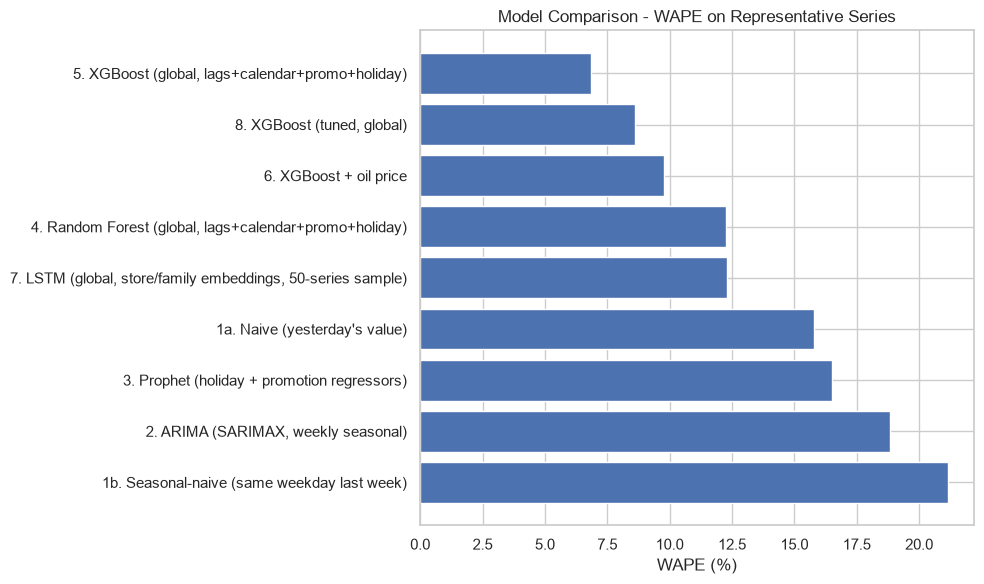

In [100]:
def plot_model_comparison(results_df):
    plt.figure(figsize=(10, 6))
    order = results_df.sort_values("WAPE_%")
    plt.barh(order["Experiment"], order["WAPE_%"], color="#4C72B0")
    plt.xlabel("WAPE (%)")
    plt.title("Model Comparison - WAPE on Representative Series")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/16_model_comparison_bar.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_model_comparison(final_results_df)

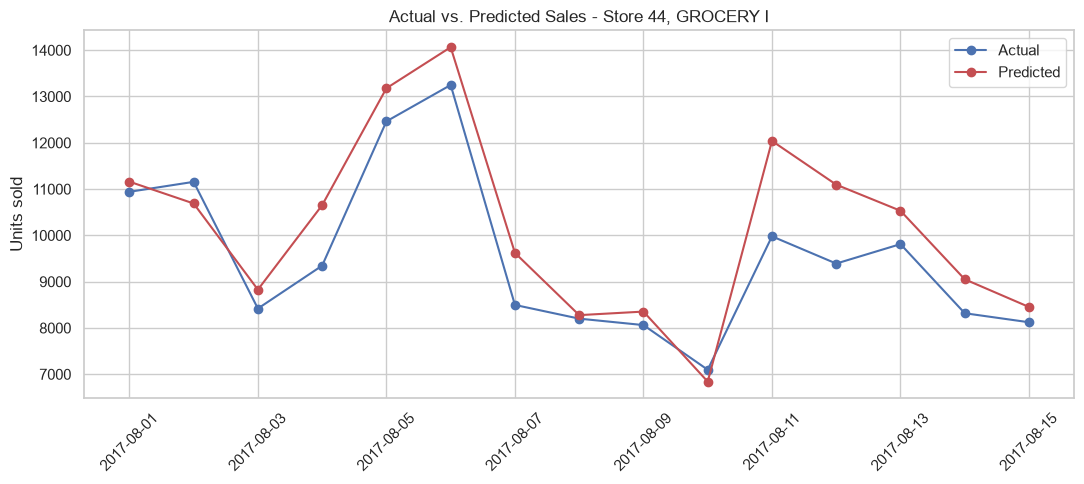

In [101]:
def plot_actual_vs_predicted(store_nbr, family, test_dates, y_true, y_pred):
    plt.figure(figsize=(11, 5))
    plt.plot(test_dates, y_true, label="Actual", marker="o", color="#4C72B0")
    plt.plot(test_dates, y_pred, label="Predicted", marker="o", color="#C44E52")
    plt.title(f"Actual vs. Predicted Sales - Store {store_nbr}, {family}")
    plt.ylabel("Units sold")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/17_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
    plt.show()


example_store, example_family = representative_series[0]
example_mask = (test_df["store_nbr"] == example_store) & (test_df.get(f"family_{example_family}", 0) == 1)
example_dates = test_df.loc[example_mask, "date"]
example_true = test_df.loc[example_mask, "sales"].values
example_pred = final_model.predict(test_df.loc[example_mask, final_feature_cols])

plot_actual_vs_predicted(example_store, example_family, example_dates, example_true, example_pred)

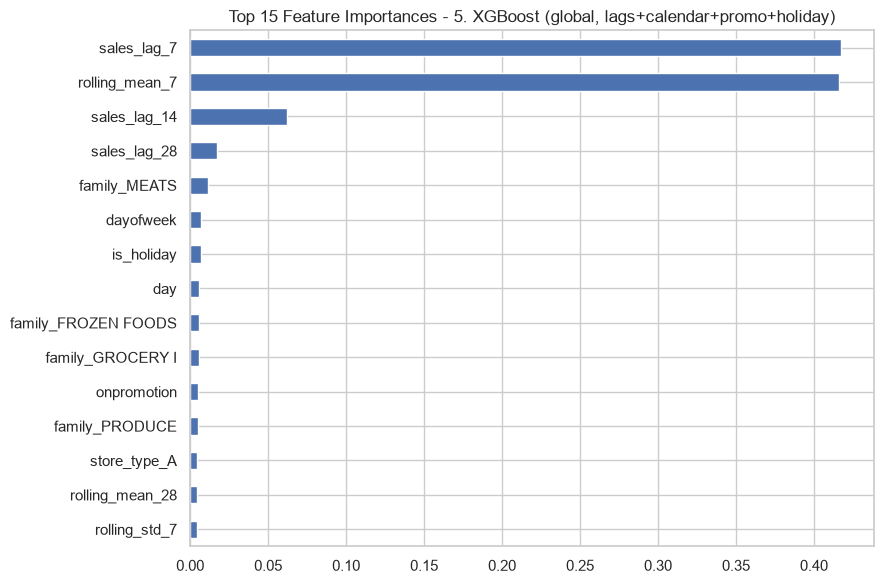

In [102]:
def plot_feature_importance(model, feature_names, top_n=15):
    if not hasattr(model, "feature_importances_"):
        print("Selected final model has no .feature_importances_ attribute - skipping this plot "
              "(expected if ARIMA, Prophet, or the LSTM won the comparison above).")
        return

    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(9, 6))
    importances.plot(kind="barh", color="#4C72B0")
    plt.gca().invert_yaxis()
    plt.title(f"Top {top_n} Feature Importances - {final_model_name}")
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/18_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_feature_importance(final_model, final_feature_cols)

## 6. Act - Recommendations and Next Steps

In [103]:
print(f"Selected final model: {final_model_name}")
print("Full-test-set metrics:")
print(global_results_df[global_results_df["Experiment"] == final_model_name])


Selected final model: 5. XGBoost (global, lags+calendar+promo+holiday)
Full-test-set metrics:
                                         Experiment        RMSE     WAPE_%  \
0  5. XGBoost (global, lags+calendar+promo+holiday)  198.281296  12.934275   

     Bias_%  
0  2.982212  


### Recommendations

- Deploy the winning global XGBoost model across all ~1,782 series — it's the only track here actually trained and validated at that full scale, versus ARIMA/Prophet/LSTM, which were only validated on a sample.
- Use forecast bias **per product family**, not just the aggregate point forecast, to set safety-stock adjustments — a model that's unbiased in aggregate can still be badly biased for specific slow-moving families.
- Report WAPE alongside RMSE for any external-facing summary; drop MAPE as a decision metric — it is distorted by zero-sales and low-volume series in this dataset.
- Do not assume tuning automatically helps — always compare a tuned candidate against its untuned baseline before deploying it, exactly as the deployable-model selection logic here does.
- Treat oil price as an ablation experiment, not a production feature — check its effect on WAPE at the store x family granularity before promoting it.

### Limitations

- Sales here are *realized* sales, not true demand - stockouts can under-report demand on some days, so a model trained on this data may still be blind to how much was actually wanted, not just sold.
- Every one of the ~1,782 series has four missing 25-Dec dates. Before global feature engineering, those closure dates are restored to each daily series with zero sales and promotions, so lag and rolling features retain their calendar meaning.
- Forecast horizon: the lag/rolling features use actuals through the previous day, so the naive, Random Forest, XGBoost and LSTM results are one-day-ahead forecasts, not 15-day-ahead. ARIMA and Prophet forecast the whole window from one origin (multi-step), so their scores are not like-for-like with the others.
- Deployable global candidates are selected by validation WAPE; the separate 15-day test window is used only for final evaluation.
- Hyperparameter tuning (Experiment 8) did not outperform the untuned XGBoost (Experiment 5) in the run reported here - a reminder that a tuned model isn't automatically the better choice, and that the final-model selection logic in Analyze picks by actual WAPE rather than assuming the more-tuned model wins.
- ARIMA, Prophet, and the LSTM were only fit/validated on a sample of series (5 for the classical models, 50 for the LSTM) rather than the full ~1,782 - a fair comparison at full scale would need to run all of them across every series, which was out of scope for a first pass given per-series fitting time.
- The LSTM is trained on unscaled sales with a validation split that is not time-based, so it is best read as an undertrained baseline rather than a fair verdict on deep-learning models.
- Only National-level holidays were applied uniformly to every store; Regional/Local holidays (which need matching each store's city/state) were left out of the holiday flag.
- MAPE is unreliable here - zero-actual rows are excluded from it and low-volume series with small nonzero actuals inflate it - so WAPE and bias are reported alongside it.
- The dataset ends in 2017 and reflects Ecuador-specific holidays and an oil-dependent economy; conclusions about which features matter most may not transfer to a different country or retailer without re-validation.
